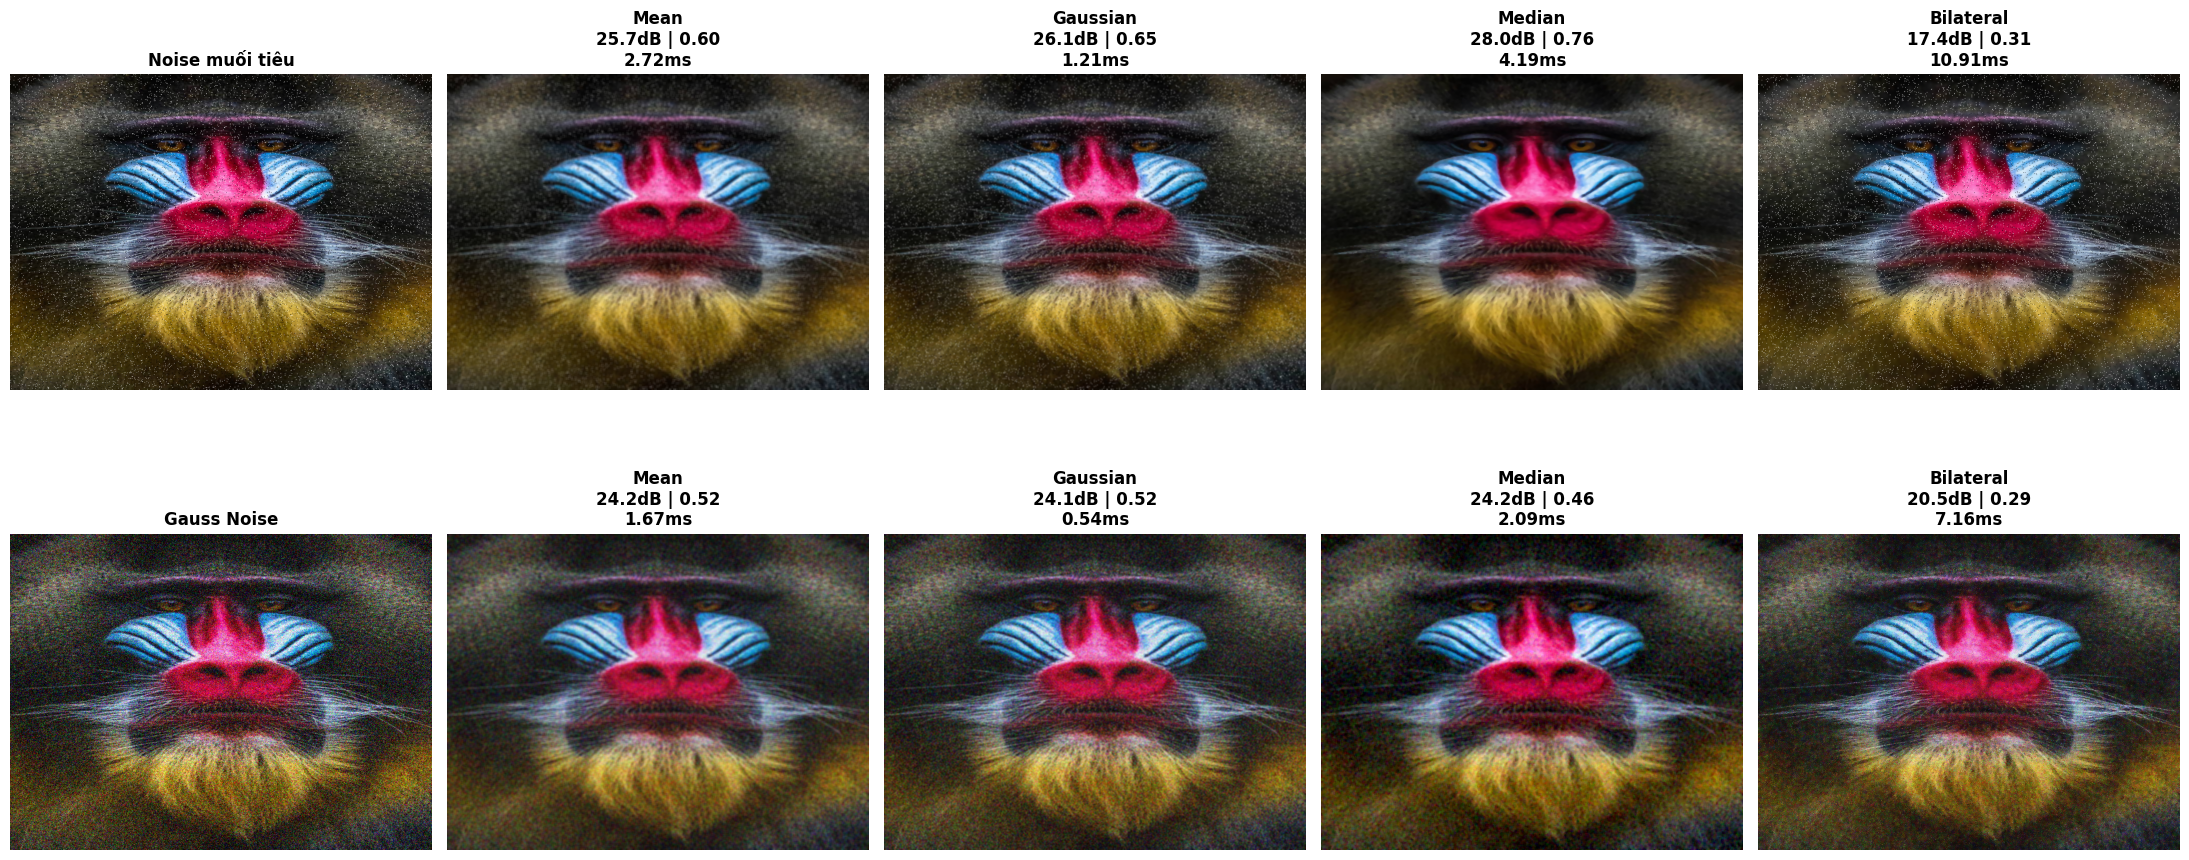

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time


def get_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0: return 100.0
    return 20 * np.log10(255.0 / np.sqrt(mse))

def get_ssim(img1, img2):

    C1, C2 = 6.5025, 58.5225
    img1, img2 = img1.astype(np.float64), img2.astype(np.float64)
    mu1 = cv2.GaussianBlur(img1, (11, 11), 1.5)
    mu2 = cv2.GaussianBlur(img2, (11, 11), 1.5)
    mu1_sq, mu2_sq, mu1_mu2 = mu1**2, mu2**2, mu1*mu2
    sigma1_sq = cv2.GaussianBlur(img1**2, (11, 11), 1.5) - mu1_sq
    sigma2_sq = cv2.GaussianBlur(img2**2, (11, 11), 1.5) - mu2_sq
    sigma12 = cv2.GaussianBlur(img1*img2, (11, 11), 1.5) - mu1_mu2
    ssim_map = ((2*mu1_mu2 + C1)*(2*sigma12 + C2)) / ((mu1_sq + mu2_sq + C1)*(sigma1_sq + sigma2_sq + C2))
    return np.mean(ssim_map)


img = cv2.imread('../input/lab_image.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_rgb = cv2.resize(img_rgb, (800, 600)) 


def add_sp(img, ratio=0.05):
    res = img.copy()
    mask = np.random.rand(img.shape[0], img.shape[1])
    res[mask < ratio/2] = [0,0,0]; res[mask > 1-ratio/2] = [255,255,255]
    return res

def add_gauss(img, sigma=50):
    noise = np.random.normal(0, sigma, img.shape).astype(np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

img_sp = add_sp(img_rgb)
img_gn = add_gauss(img_rgb)


tasks = [
    (img_sp, "Mean", cv2.blur, [(5,5)]),
    (img_sp, "Gaussian", cv2.GaussianBlur, [(5,5), 0]),
    (img_sp, "Median", cv2.medianBlur, [5]),
    (img_sp, "Bilateral", cv2.bilateralFilter, [9, 75, 75]),
    
    (img_gn, "Mean", cv2.blur, [(5,5)]),
    (img_gn, "Gaussian", cv2.GaussianBlur, [(5,5), 0]),
    (img_gn, "Median", cv2.medianBlur, [5]),
    (img_gn, "Bilateral", cv2.bilateralFilter, [9, 75, 75])
]


processed_images = [img_sp, img_gn] 
stats = []

for noise_img, name, func, args in tasks:
    start = time.time()
    res = func(noise_img, *args)
    duration = (time.time() - start) * 1000 
    
    psnr_v = get_psnr(img_rgb, res)
    ssim_v = get_ssim(img_rgb, res)
    
    processed_images.append(res)
    stats.append(f"{name}\n{psnr_v:.1f}dB | {ssim_v:.2f}\n{duration:.2f}ms")


titles = ["Noise muối tiêu", "Gauss Noise"] + stats 
display_order = [0, 2, 3, 4, 5, 1, 6, 7, 8, 9]

plt.figure(figsize=(22, 10))
for i, idx in enumerate(display_order):
    plt.subplot(2, 5, i + 1)
    plt.imshow(processed_images[idx])
    plt.title(titles[idx] if idx < 2 else titles[idx], fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()